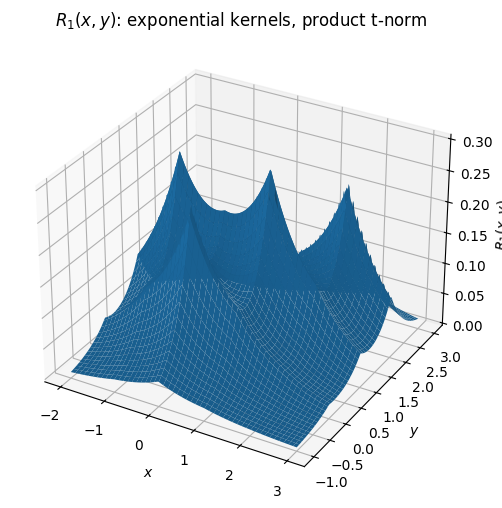

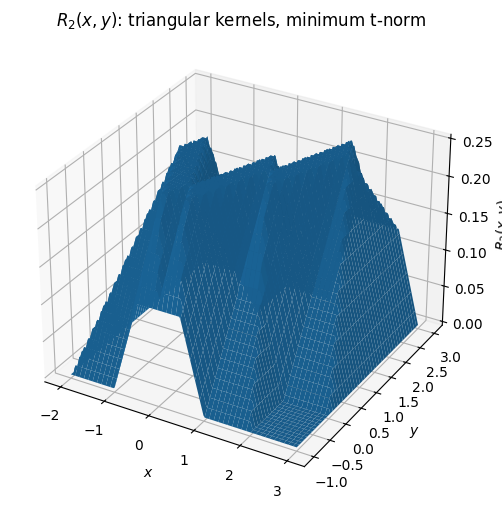

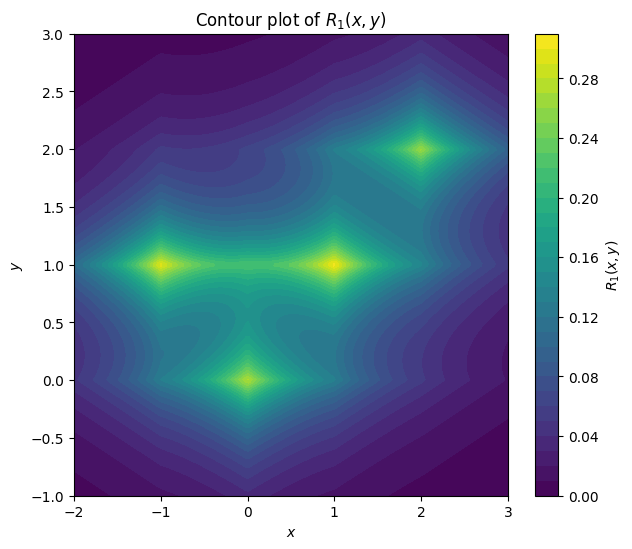

<Figure size 640x480 with 0 Axes>

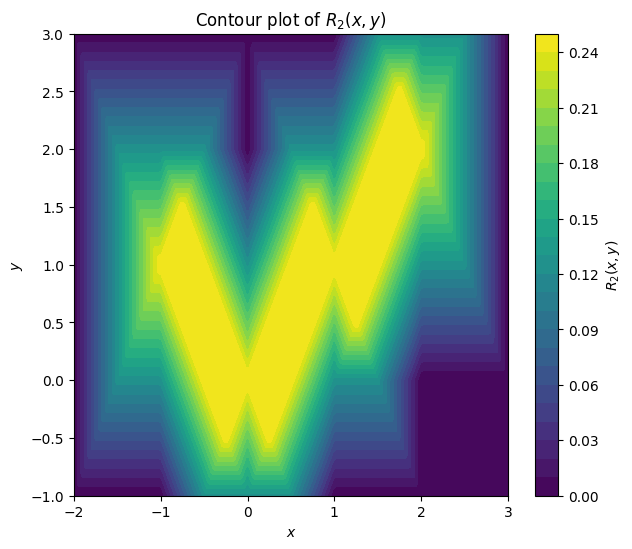

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
D = np.array([
    [-1, 1],
    [0, 0],
    [1, 1],
    [2, 2]
])
D2 = np.array([
    [0, 0],
    [1, 1],
    [2, 0]
])


def R1(x, y):

    total = 0
    for xi, yi in D:
        f1 = np.exp(-np.abs(xi - x))
        f2 = np.exp(-2 * np.abs(yi - y))
        total += f1 * f2

    return total / len(D)


def R2(x, y):

    total = 0
    for xi, yi in D:
        f1 = np.maximum(1 - np.abs(xi - x), 0)
        f2 = np.maximum(1 - np.abs(yi - y) / 2, 0)
        total += np.minimum(f1, f2)

    return total / len(D)


# Grid
x = np.linspace(-2, 3, 200)
y = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x, y)

Z1 = R1(X, Y)
Z2 = R2(X, Y)


# Plot R1
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z1)
ax.set_title(r"$R_1(x,y)$: exponential kernels, product t-norm")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$R_1(x,y)$")
plt.show()


# Plot R2
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z2)
ax.set_title(r"$R_2(x,y)$: triangular kernels, minimum t-norm")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$R_2(x,y)$")
plt.show()


# Contour plot R1
plt.figure(figsize=(7, 6))
plt.contourf(X, Y, Z1, levels=30)
plt.colorbar(label=r"$R_1(x,y)$")
plt.title(r"Contour plot of $R_1(x,y)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.show()
plt.savefig(
    "R1_contour.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# Contour plot R2
plt.figure(figsize=(7, 6))
plt.contourf(X, Y, Z2, levels=30)
plt.colorbar(label=r"$R_2(x,y)$")
plt.title(r"Contour plot of $R_2(x,y)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.show()
plt.savefig(
    "R2_contour.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


Approximation of R1
-------------------
delta1: 0.35
number of x-centers: 16
number of y-centers: 13
maximum error: 0.16511333508903758
mean error: 0.017618299361797873

Approximation of R2
-------------------
delta1: 0.35
number of x-centers: 16
number of y-centers: 13
maximum error: 0.17078313253012078
mean error: 0.042945168617326474


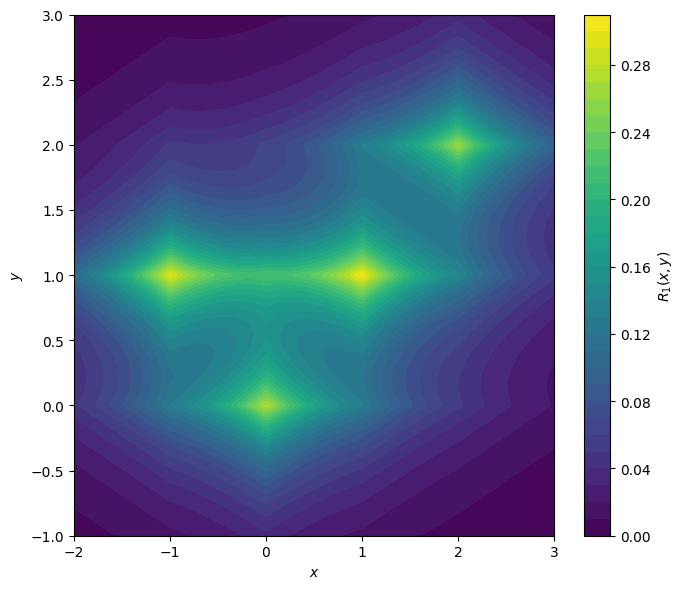

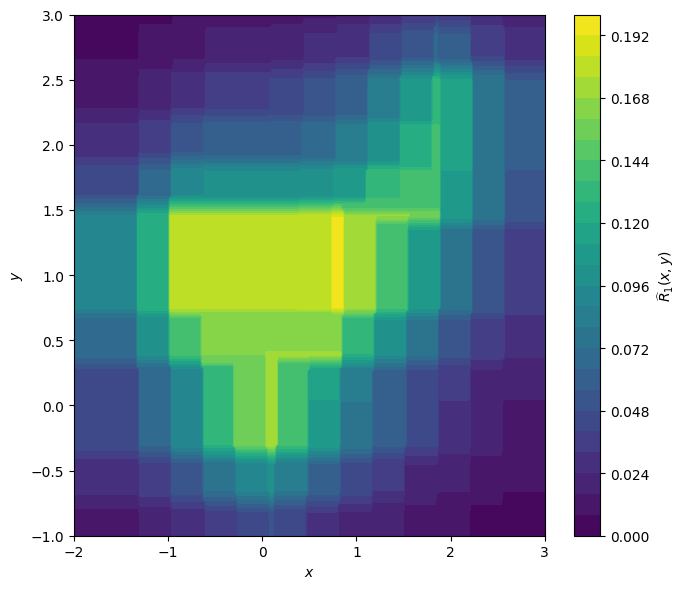

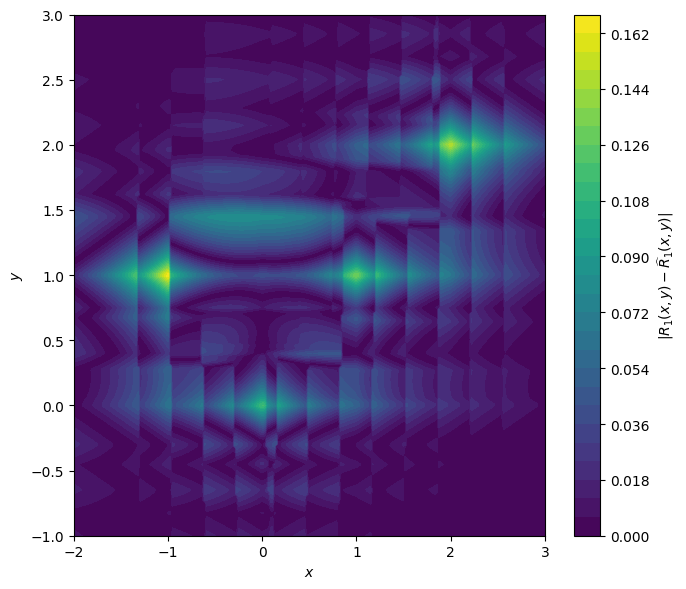

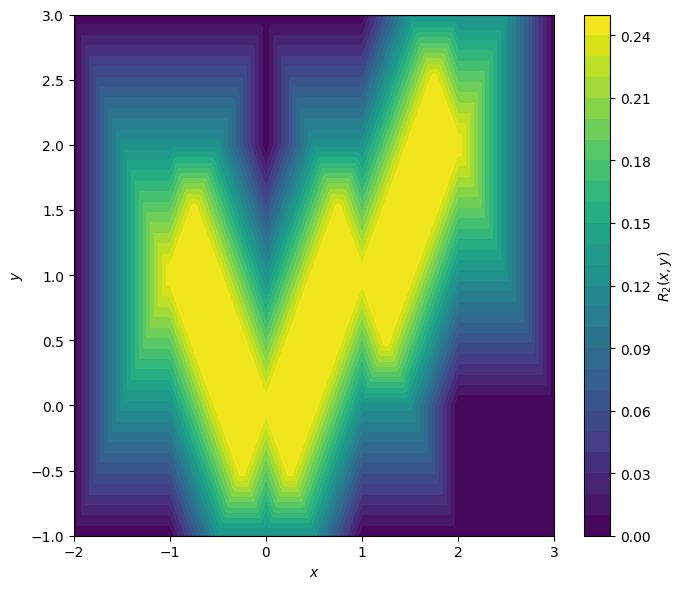

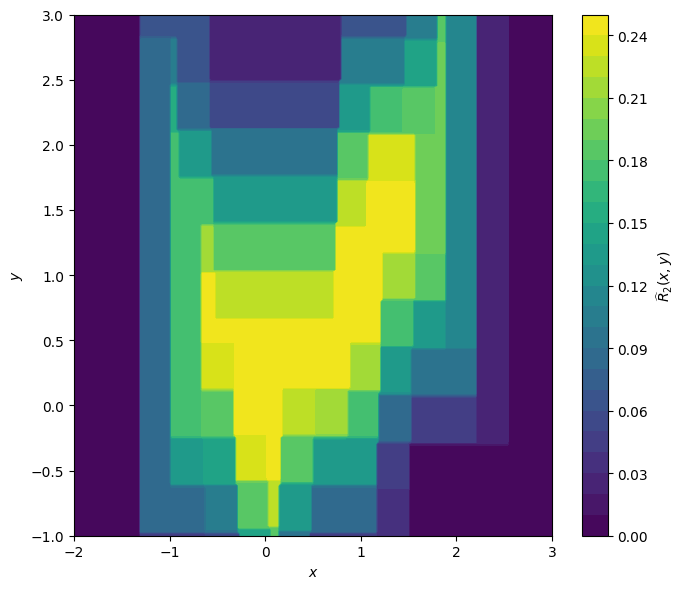

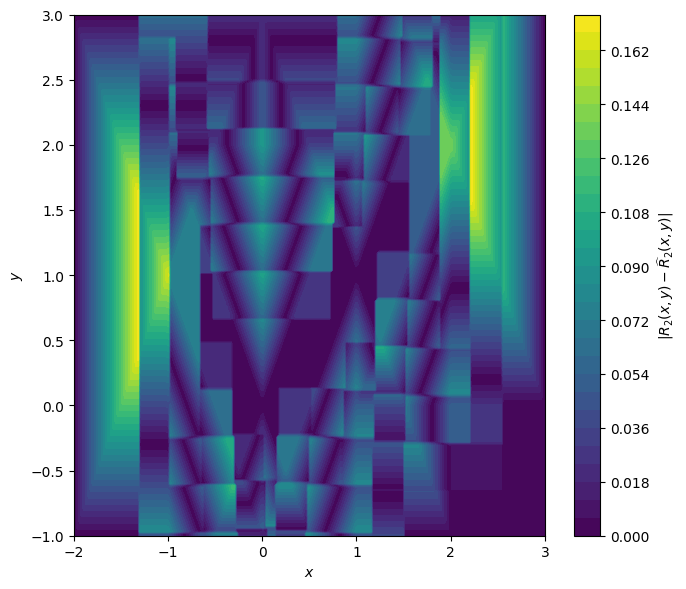

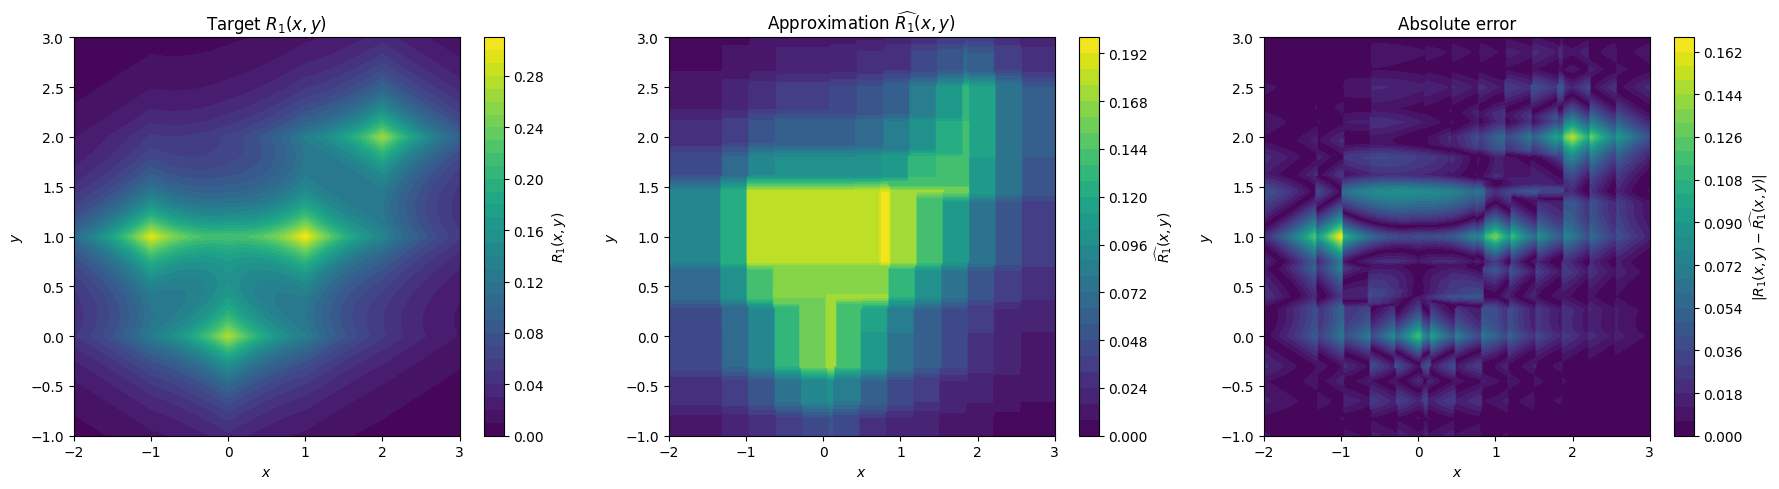

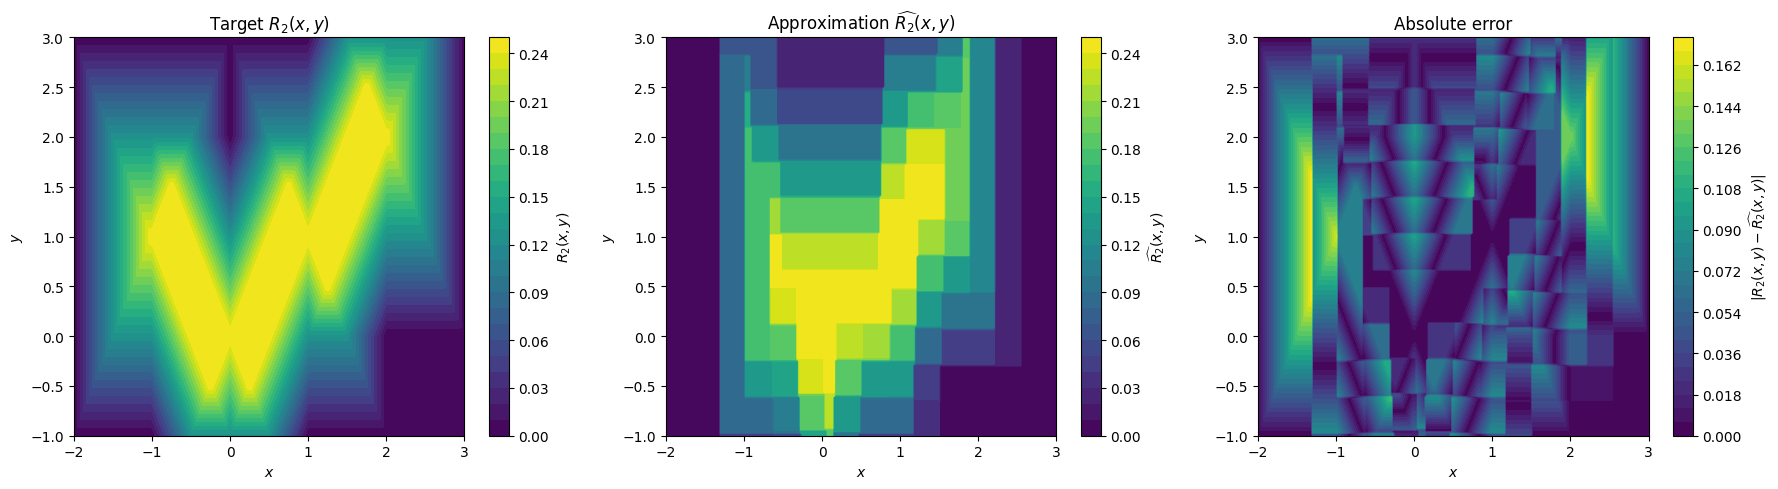

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Output folder
# ============================================================

os.makedirs("img", exist_ok=True)


# ============================================================
# Data matrix
# ============================================================

D = np.array([
    [-1, 1],
    [0, 0],
    [1, 1],
    [2, 2]
])


# ============================================================
# Target fuzzy relations R1 and R2
# ============================================================

def R1(x, y):
    """
    Exponential kernels with product t-norm.

    R1(x,y) =
        1/4 sum_i exp(-|x_i-x|) exp(-2|y_i-y|)
    """
    total = 0

    for xi, yi in D:
        f1 = np.exp(-np.abs(xi - x))
        f2 = np.exp(-2 * np.abs(yi - y))
        total += f1 * f2

    return total / len(D)


def R2(x, y):
    """
    Triangular kernels with minimum t-norm.

    R2(x,y) =
        1/4 sum_i min(
            max(1-|x_i-x|,0),
            max(1-|y_i-y|/2,0)
        )
    """
    total = 0

    for xi, yi in D:
        f1 = np.maximum(1 - np.abs(xi - x), 0)
        f2 = np.maximum(1 - np.abs(yi - y) / 2, 0)
        total += np.minimum(f1, f2)

    return total / len(D)


# ============================================================
# Gödel implication
# ============================================================

def godel_implication(a, b):
    """
    Gödel implication:

        a ->_G b = 1, if a <= b,
                 = b, otherwise.

    This implication satisfies the left neutrality principle:
        1 ->_G b = b.
    """
    return np.where(a <= b, 1.0, b)


# ============================================================
# T-norms
# ============================================================

def product_tnorm(a, b):
    return a * b


def minimum_tnorm(a, b):
    return np.minimum(a, b)


# ============================================================
# Fuzzy balls A_x and B_y from the theorem
# ============================================================

def fuzzy_ball(z, center, delta1):
    """
    Implements the fuzzy set

        A_center(z) = min(1, max(0, 2 - |z-center|/delta1)).

    If |z-center| < delta1, then A_center(z) = 1.
    If |z-center| >= 2 delta1, then A_center(z) = 0.
    """
    return np.minimum(
        1.0,
        np.maximum(0.0, 2.0 - np.abs(z - center) / delta1)
    )


# ============================================================
# Weighted implicative approximation
# ============================================================

def weighted_implicative_approximation(
    X,
    Y,
    R_target,
    x_centers,
    y_centers,
    delta1,
    conjunction
):
    """
    Computes

        R_hat(s,t)
        =
        inf_{A_x in A}
        [
            A_x(s) -> sup_{B_y in B}
            ( q(A_x,B_y) conjunction B_y(t) )
        ],

    where

        q(A_x,B_y) = R_target(x,y).

    In the discrete numerical implementation:
        inf = minimum,
        sup = maximum.
    """

    R_hat = np.ones_like(X)

    # Quantifier table Q[i,j] = q(A_x_i, B_y_j) = R(x_i,y_j)
    Q = np.zeros((len(x_centers), len(y_centers)))

    for i, cx in enumerate(x_centers):
        for j, cy in enumerate(y_centers):
            Q[i, j] = R_target(cx, cy)

    # Compute infimum over antecedent fuzzy sets A_x
    for i, cx in enumerate(x_centers):

        A_i = fuzzy_ball(X, cx, delta1)

        # Compute supremum over consequent fuzzy sets B_y
        inner_sup = np.zeros_like(X)

        for j, cy in enumerate(y_centers):

            B_j = fuzzy_ball(Y, cy, delta1)

            value = conjunction(Q[i, j], B_j)

            inner_sup = np.maximum(inner_sup, value)

        F_i = godel_implication(A_i, inner_sup)

        R_hat = np.minimum(R_hat, F_i)

    return R_hat


# ============================================================
# Compact domains and computational grid
# ============================================================

x_min, x_max = -2, 3
y_min, y_max = -1, 3

n_grid = 250

x = np.linspace(x_min, x_max, n_grid)
y = np.linspace(y_min, y_max, n_grid)

X, Y = np.meshgrid(x, y)


# ============================================================
# Finite coverings of X and Y
# ============================================================

# Smaller delta1 means more fuzzy sets and usually better approximation.
# Try, for example:
# delta1 = 0.5
# delta1 = 0.35
# delta1 = 0.25
# delta1 = 0.2

delta1 = 0.35

x_centers = np.arange(x_min, x_max + delta1, delta1)
y_centers = np.arange(y_min, y_max + delta1, delta1)


# ============================================================
# Compute target relations
# ============================================================

Z1 = R1(X, Y)
Z2 = R2(X, Y)


# ============================================================
# Compute approximations
# ============================================================

Z1_hat = weighted_implicative_approximation(
    X=X,
    Y=Y,
    R_target=R1,
    x_centers=x_centers,
    y_centers=y_centers,
    delta1=delta1,
    conjunction=product_tnorm
)

Z2_hat = weighted_implicative_approximation(
    X=X,
    Y=Y,
    R_target=R2,
    x_centers=x_centers,
    y_centers=y_centers,
    delta1=delta1,
    conjunction=minimum_tnorm
)


# ============================================================
# Errors
# ============================================================

E1 = np.abs(Z1 - Z1_hat)
E2 = np.abs(Z2 - Z2_hat)

print("Approximation of R1")
print("-------------------")
print("delta1:", delta1)
print("number of x-centers:", len(x_centers))
print("number of y-centers:", len(y_centers))
print("maximum error:", np.max(E1))
print("mean error:", np.mean(E1))
print()

print("Approximation of R2")
print("-------------------")
print("delta1:", delta1)
print("number of x-centers:", len(x_centers))
print("number of y-centers:", len(y_centers))
print("maximum error:", np.max(E2))
print("mean error:", np.mean(E2))


# ============================================================
# Plotting functions
# ============================================================

def save_contour(Z, title, colorbar_label, filename):
    plt.figure(figsize=(7, 6))
    plt.contourf(X, Y, Z, levels=30)
    plt.colorbar(label=colorbar_label)
    #plt.title(title)
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()


def save_comparison(Z, Z_hat, E, relation_name, filename):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    panels = [
        (
            Z,
            rf"Target ${relation_name}(x,y)$",
            rf"${relation_name}(x,y)$"
        ),
        (
            Z_hat,
            rf"Approximation $\widehat{{{relation_name}}}(x,y)$",
            rf"$\widehat{{{relation_name}}}(x,y)$"
        ),
        (
            E,
            "Absolute error",
            rf"$|{relation_name}(x,y)-\widehat{{{relation_name}}}(x,y)|$"
        )
    ]

    for ax, (Z_current, title, label) in zip(axes, panels):
        c = ax.contourf(X, Y, Z_current, levels=30)
        fig.colorbar(c, ax=ax, label=label)
        ax.set_title(title)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")

    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()


# ============================================================
# Save individual figures
# ============================================================

save_contour(
    Z1,
    r"Target relation $R_1(x,y)$",
    r"$R_1(x,y)$",
    "img/R1_target.png"
)

save_contour(
    Z1_hat,
    r"Weighted implicative approximation $\widehat{R}_1(x,y)$",
    r"$\widehat{R}_1(x,y)$",
    "img/R1_approximation.png"
)

save_contour(
    E1,
    r"Absolute error $|R_1(x,y)-\widehat{R}_1(x,y)|$",
    r"$|R_1(x,y)-\widehat{R}_1(x,y)|$",
    "img/R1_error.png"
)

save_contour(
    Z2,
    r"Target relation $R_2(x,y)$",
    r"$R_2(x,y)$",
    "img/R2_target.png"
)

save_contour(
    Z2_hat,
    r"Weighted implicative approximation $\widehat{R}_2(x,y)$",
    r"$\widehat{R}_2(x,y)$",
    "img/R2_approximation.png"
)

save_contour(
    E2,
    r"Absolute error $|R_2(x,y)-\widehat{R}_2(x,y)|$",
    r"$|R_2(x,y)-\widehat{R}_2(x,y)|$",
    "img/R2_error.png"
)


# ============================================================
# Save combined figures
# ============================================================

save_comparison(
    Z1,
    Z1_hat,
    E1,
    "R_1",
    "img/R1_target_approx_error.png"
)

save_comparison(
    Z2,
    Z2_hat,
    E2,
    "R_2",
    "img/R2_target_approx_error.png"
)